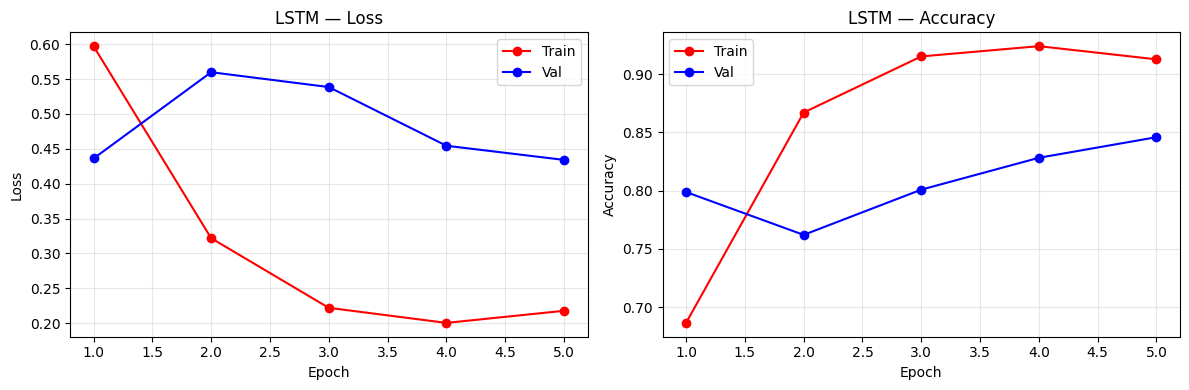

79/79 ━━━━━━━━━━━━━━━━━━━━ 69s 876ms/step - accuracy: 0.9157 - loss: 0.2114 - val_accuracy: 0.8458 - val_loss: 0.4341

LSTM Test Accuracy: 0.8458


In [1]:
# ==============================
# Week 11 : IMDB LSTM
# ==============================

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, clear_output
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import Callback

tf.random.set_seed(42)
np.random.seed(42)

VOCAB_SIZE = 10000
MAX_LEN = 200
NUM_SAMPLES = 10000
EMBED_DIM = 128

(X_train, y_train), (X_test, y_test) = imdb.load_data(num_words=VOCAB_SIZE)
X_train, y_train = X_train[:NUM_SAMPLES], y_train[:NUM_SAMPLES]
X_train = pad_sequences(X_train, maxlen=MAX_LEN)
X_test = pad_sequences(X_test, maxlen=MAX_LEN)

class LivePlot(Callback):
    def on_train_begin(self, logs=None):
        self.h = {k: [] for k in ['loss','val_loss','accuracy','val_accuracy']}
    def on_epoch_end(self, epoch, logs=None):
        for k in self.h: self.h[k].append(logs[k])
        ep = range(1, epoch + 2)
        clear_output(wait=True)
        fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 4))
        a1.plot(ep, self.h['loss'], 'r-o', label='Train'); a1.plot(ep, self.h['val_loss'], 'b-o', label='Val')
        a1.set(title='LSTM — Loss', xlabel='Epoch', ylabel='Loss'); a1.legend(); a1.grid(True, alpha=.3)
        a2.plot(ep, self.h['accuracy'], 'r-o', label='Train'); a2.plot(ep, self.h['val_accuracy'], 'b-o', label='Val')
        a2.set(title='LSTM — Accuracy', xlabel='Epoch', ylabel='Accuracy'); a2.legend(); a2.grid(True, alpha=.3)
        fig.tight_layout(); display(fig); plt.close(fig)

model = tf.keras.Sequential([
    tf.keras.layers.Embedding(VOCAB_SIZE, EMBED_DIM),
    tf.keras.layers.LSTM(64),
    tf.keras.layers.Dense(16, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

model.fit(X_train, y_train, epochs=5, batch_size=128,
          validation_data=(X_test, y_test), callbacks=[LivePlot()])

loss, acc = model.evaluate(X_test, y_test, verbose=0)
print(f"\nLSTM Test Accuracy: {acc:.4f}")